In [48]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt
import plotly.io as pio

## For Airbnb dataset

In [49]:
print("Librerías importadas y configuración lista.")

df = pl.read_csv("../14_aug/listings.csv")
print(df)

Librerías importadas y configuración lista.
shape: (26_067, 79)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ listing_u ┆ scrape_id ┆ last_scra ┆ … ┆ calculate ┆ calculate ┆ calculate ┆ reviews_ │
│ ---       ┆ rl        ┆ ---       ┆ ped       ┆   ┆ d_host_li ┆ d_host_li ┆ d_host_li ┆ per_mont │
│ i64       ┆ ---       ┆ i64       ┆ ---       ┆   ┆ stings_co ┆ stings_co ┆ stings_co ┆ h        │
│           ┆ str       ┆           ┆ str       ┆   ┆ unt…      ┆ unt…      ┆ unt…      ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ i64       ┆ i64       ┆ i64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 35797     ┆ https://w ┆ 202503191 ┆ 2025-03-2 ┆ … ┆ 1         ┆ 0         ┆ 0         ┆ null     │
│           ┆ ww.airbnb ┆ 5

In [50]:
df.describe()

statistic,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,…,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
str,f64,str,f64,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,f64,f64,str,str,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""count""",26067.0,"""26067""",26067.0,"""26067""","""26067""","""26067""","""25300""","""14391""","""26067""",26067.0,"""26067""","""26062""","""26062""","""20587""","""26062""","""26062""","""26062""","""26062""","""24724""","""26062""","""26062""","""13875""",26062.0,26062.0,"""26067""","""26062""","""26062""","""14391""","""26067""","""0""",26067.0,26067.0,"""26067""","""26067""",26067.0,22062.0,…,26067.0,26067.0,26067.0,26067.0,26067.0,26067.0,26067.0,"""0""","""25076""",26067.0,26067.0,26067.0,26067.0,"""26067""",26067.0,26067.0,26067.0,26067.0,26067.0,26067.0,22068.0,"""22806""","""22806""",22806.0,22805.0,22805.0,22805.0,22805.0,22805.0,22805.0,"""0""","""26067""",26067.0,26067.0,26067.0,26067.0,22806.0
"""null_count""",0.0,"""0""",0.0,"""0""","""0""","""0""","""767""","""11676""","""0""",0.0,"""0""","""5""","""5""","""5480""","""5""","""5""","""5""","""5""","""1343""","""5""","""5""","""12192""",5.0,5.0,"""0""","""5""","""5""","""11676""","""0""","""26067""",0.0,0.0,"""0""","""0""",0.0,4005.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""26067""","""991""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,3999.0,"""3261""","""3261""",3261.0,3262.0,3262.0,3262.0,3262.0,3262.0,3262.0,"""26067""","""0""",0.0,0.0,0.0,0.0,3261.0
"""mean""",6.0413e17,null,2.0250e13,null,null,null,null,null,null,2.2885e8,null,null,null,null,null,null,null,null,null,null,null,null,25.900852,35.072826,null,null,null,null,null,null,19.405242,-99.166046,null,null,3.34676,1.451432,…,497.850424,4.326275,4.861396,83078.227414,83105.265585,4.553466,83091.158453,null,null,12.807151,32.647869,54.661564,218.320865,null,50.484751,15.173246,1.221046,178.373231,14.514482,82.529098,137057.075856,null,null,4.750332,4.783535,4.753931,4.837276,4.823005,4.840322,4.713932,null,null,15.491886,12.622626,2.690068,0.141904,1.803389
"""std""",5.2659e17,null,0.0,null,null,null,null,null,null,1.9542e8,null,null,null,null,null,null,null,null,null,null,null,null,86.765206,123.984298,null,null,null,null,null,null,0.042514,0.033489,null,null,2.359036,1.030367,…,409.415054,24.438706,24.862708,1.3301e7,1.3301e7,24.536108,1.3301e7,null,null,10.623744,21.202736,31.571305,130.073992,null,79.867601,22.005051,1.922822,102.101943,21.68007,89.755021,281565.332008,null,null,0.381077,0.372396,0.378514,0.326791,0.360575,0.29821,0.394899,null,null,36.230505,35.795452,7

### Calculate means

In [51]:
means = df.mean()
print(means)

shape: (1, 79)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ listing_u ┆ scrape_id ┆ last_scra ┆ … ┆ calculate ┆ calculate ┆ calculate ┆ reviews_ │
│ ---       ┆ rl        ┆ ---       ┆ ped       ┆   ┆ d_host_li ┆ d_host_li ┆ d_host_li ┆ per_mont │
│ f64       ┆ ---       ┆ f64       ┆ ---       ┆   ┆ stings_co ┆ stings_co ┆ stings_co ┆ h        │
│           ┆ str       ┆           ┆ str       ┆   ┆ unt…      ┆ unt…      ┆ unt…      ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 6.0413e17 ┆ null      ┆ 2.0250e13 ┆ null      ┆ … ┆ 12.622626 ┆ 2.690068  ┆ 0.141904  ┆ 1.803389 │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────

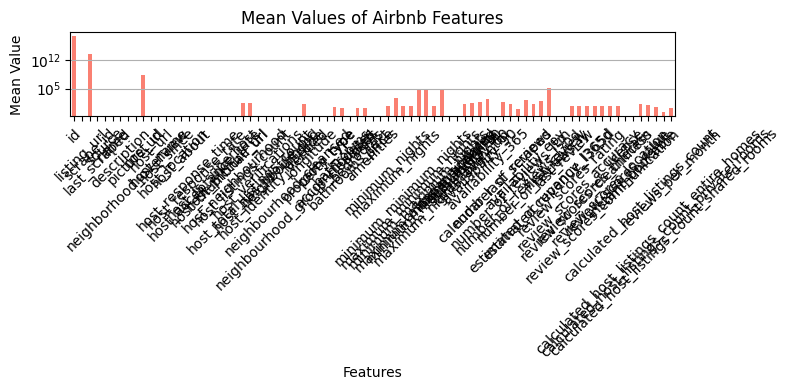

In [52]:
means_pd = means.to_pandas().T
means_pd.columns = ["Mean"]

plt.figure(figsize=(8, 4))
means_pd["Mean"].plot(kind="bar", color="salmon")
plt.title('Mean Values of Airbnb Features')
plt.ylabel('Mean Value')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.yscale("log")
plt.tight_layout()
plt.show()

### Calculate medians

In [53]:
medians = df.median()
print(medians)

shape: (1, 79)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ listing_u ┆ scrape_id ┆ last_scra ┆ … ┆ calculate ┆ calculate ┆ calculate ┆ reviews_ │
│ ---       ┆ rl        ┆ ---       ┆ ped       ┆   ┆ d_host_li ┆ d_host_li ┆ d_host_li ┆ per_mont │
│ f64       ┆ ---       ┆ f64       ┆ ---       ┆   ┆ stings_co ┆ stings_co ┆ stings_co ┆ h        │
│           ┆ str       ┆           ┆ str       ┆   ┆ unt…      ┆ unt…      ┆ unt…      ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 7.3984e17 ┆ null      ┆ 2.0250e13 ┆ null      ┆ … ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ 1.23     │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────

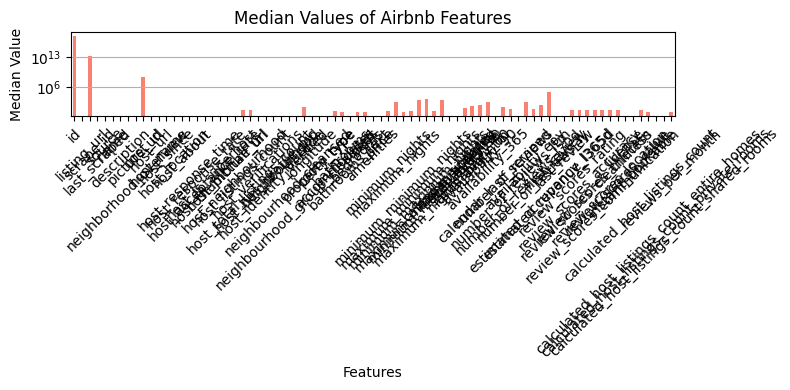

In [54]:
medians_pd = medians.to_pandas().T
medians_pd.columns = ["Median"]

plt.figure(figsize=(8, 4))
medians_pd["Median"].plot(kind="bar", color="salmon")
plt.title('Median Values of Airbnb Features')
plt.ylabel('Median Value')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.yscale("log")
plt.tight_layout()
plt.show()

### Calculate modes

In [55]:
modes_first = {}
for col in df.columns:
    col_modes = df.select(pl.col(col).mode())[col].to_list()
    modes_first[col] = col_modes[0] if col_modes else None

print(modes_first)

{'id': 40139473, 'listing_url': 'https://www.airbnb.com/rooms/1055178569431083469', 'scrape_id': 20250319150644, 'last_scraped': '2025-03-20', 'source': 'city scrape', 'name': 'Blueground | Roma Sur 1 recamara, AC & rooftop', 'description': None, 'neighborhood_overview': None, 'picture_url': 'https://a0.muscache.com/pictures/miso/Hosting-822350398158819419/original/0b826239-bcec-4cac-9f40-73705e476cbb.jpeg', 'host_id': 498701635, 'host_url': 'https://www.airbnb.com/users/show/498701635', 'host_name': 'Alejandra', 'host_since': '2023-01-30', 'host_location': 'Mexico City, Mexico', 'host_about': '', 'host_response_time': 'within an hour', 'host_response_rate': '100%', 'host_acceptance_rate': '100%', 'host_is_superhost': 'f', 'host_thumbnail_url': 'https://a0.muscache.com/defaults/user_pic-50x50.png?v=3', 'host_picture_url': 'https://a0.muscache.com/defaults/user_pic-225x225.png?v=3', 'host_neighbourhood': None, 'host_listings_count': 1, 'host_total_listings_count': 1, 'host_verifications

## For Ecobici datase

In [56]:
print("Librerías importadas y configuración lista.")

df = pl.read_csv("../18_aug/2025-01.csv",
ignore_errors=True)
print(df)

Librerías importadas y configuración lista.
shape: (1_809_775, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ Genero_Usu ┆ Edad_Usua ┆ Bici    ┆ Ciclo_Est ┆ … ┆ Hora_Reti ┆ Ciclo_Est ┆ Fecha_Arr ┆ Hora_Arri │
│ ario       ┆ rio       ┆ ---     ┆ acion_Ret ┆   ┆ ro        ┆ acionArri ┆ ibo       ┆ bo        │
│ ---        ┆ ---       ┆ i64     ┆ iro       ┆   ┆ ---       ┆ bo        ┆ ---       ┆ ---       │
│ str        ┆ i64       ┆         ┆ ---       ┆   ┆ str       ┆ ---       ┆ str       ┆ str       │
│            ┆           ┆         ┆ str       ┆   ┆           ┆ i64       ┆           ┆           │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ M          ┆ 26        ┆ 5180930 ┆ 568       ┆ … ┆ 23:57:02  ┆ 572       ┆ 01/01/202 ┆ 00:00:03  │
│            ┆           ┆         ┆           ┆   ┆           ┆           ┆ 5         ┆           │
│ F          ┆ 54        

### Calculate means

In [57]:
means = df.mean()
print(means)

shape: (1, 9)
┌───────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ Genero_Us ┆ Edad_Usua ┆ Bici     ┆ Ciclo_Est ┆ … ┆ Hora_Reti ┆ Ciclo_Est ┆ Fecha_Arr ┆ Hora_Arri │
│ uario     ┆ rio       ┆ ---      ┆ acion_Ret ┆   ┆ ro        ┆ acionArri ┆ ibo       ┆ bo        │
│ ---       ┆ ---       ┆ f64      ┆ iro       ┆   ┆ ---       ┆ bo        ┆ ---       ┆ ---       │
│ str       ┆ f64       ┆          ┆ ---       ┆   ┆ str       ┆ ---       ┆ str       ┆ str       │
│           ┆           ┆          ┆ str       ┆   ┆           ┆ f64       ┆           ┆           │
╞═══════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ null      ┆ 34.003515 ┆ 5.4569e6 ┆ null      ┆ … ┆ null      ┆ 286.09758 ┆ null      ┆ null      │
│           ┆           ┆          ┆           ┆   ┆           ┆ 5         ┆           ┆           │
└───────────┴───────────┴──────────┴───────────┴───┴───────────┴───────────┴─

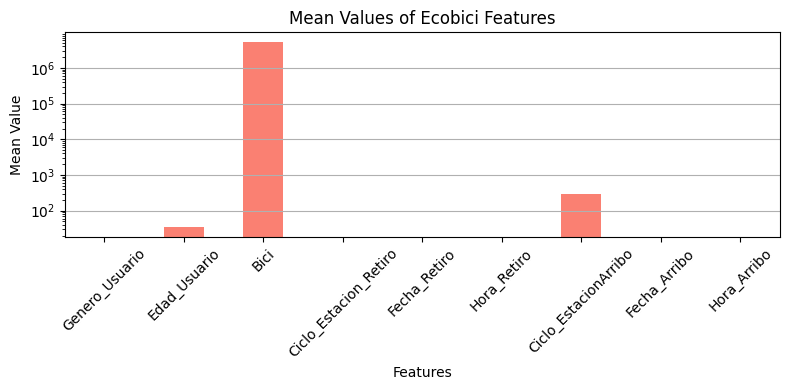

In [58]:
means_pd = means.to_pandas().T
means_pd.columns = ["Mean"]

plt.figure(figsize=(8, 4))
means_pd["Mean"].plot(kind="bar", color="salmon")
plt.title('Mean Values of Ecobici Features')
plt.ylabel('Mean Value')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.yscale("log")
plt.tight_layout()
plt.show()

### Calculate medians

In [59]:
medians = df.median()
print(medians)

shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Genero_Us ┆ Edad_Usua ┆ Bici      ┆ Ciclo_Est ┆ … ┆ Hora_Reti ┆ Ciclo_Est ┆ Fecha_Arr ┆ Hora_Arr │
│ uario     ┆ rio       ┆ ---       ┆ acion_Ret ┆   ┆ ro        ┆ acionArri ┆ ibo       ┆ ibo      │
│ ---       ┆ ---       ┆ f64       ┆ iro       ┆   ┆ ---       ┆ bo        ┆ ---       ┆ ---      │
│ str       ┆ f64       ┆           ┆ ---       ┆   ┆ str       ┆ ---       ┆ str       ┆ str      │
│           ┆           ┆           ┆ str       ┆   ┆           ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ null      ┆ 32.0      ┆ 5.452651e ┆ null      ┆ … ┆ null      ┆ 242.0     ┆ null      ┆ null     │
│           ┆           ┆ 6         ┆           ┆   ┆           ┆           ┆           ┆          │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴

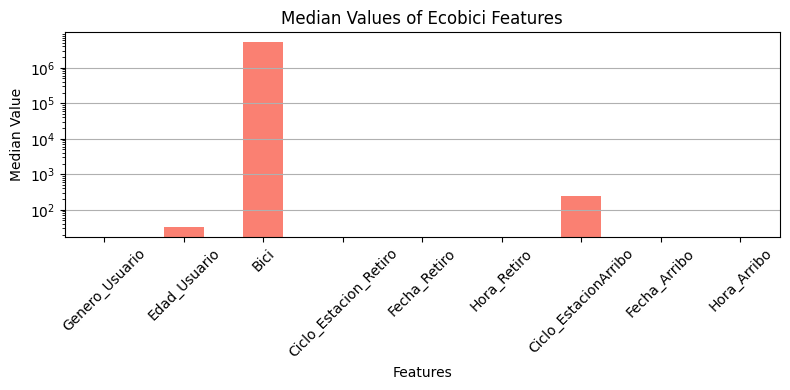

In [60]:
medians_pd = medians.to_pandas().T
medians_pd.columns = ["Median"]

plt.figure(figsize=(8, 4))
medians_pd["Median"].plot(kind="bar", color="salmon")
plt.title('Median Values of Ecobici Features')
plt.ylabel('Median Value')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.yscale("log")
plt.tight_layout()
plt.show()

### Calculate modes

In [61]:
modes_first = {}
for col in df.columns:
    col_modes = df.select(pl.col(col).mode())[col].to_list()
    modes_first[col] = col_modes[0] if col_modes else None

print(modes_first)

{'Genero_Usuario': 'M', 'Edad_Usuario': 30, 'Bici': 8537367, 'Ciclo_Estacion_Retiro': '271-272', 'Fecha_Retiro': '29/01/2025', 'Hora_Retiro': '18:05:49', 'Ciclo_EstacionArribo': None, 'Fecha_Arribo': '29/01/2025', 'Hora_Arribo': '18:34:56'}
